# Lab 12 — Deep Convolutional Neural Networks (CNNs)
### Computer Vision Lab Assignment
---
**Lab Outcomes:**
- Understand the architecture and working of a Deep CNN
- Build and train a CNN using TensorFlow and Keras
- Visualize filters, feature maps, and predictions
- Apply data augmentation and dropout for regularization
- Evaluate CNN performance using classification metrics

> **Note:** Run cells in order. All tasks are self-contained but share the same kernel state.

## 📦 Install & Import Dependencies

In [6]:
# Install required packages (uncomment if running for the first time)
# !pip install tensorflow scikit-learn matplotlib seaborn numpy

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10, mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully ✅")

TensorFlow version: 2.20.0
All libraries imported successfully ✅


---
## ✅ Solved Activities

### Activity 1: Load and Visualize Dataset (CIFAR-10)

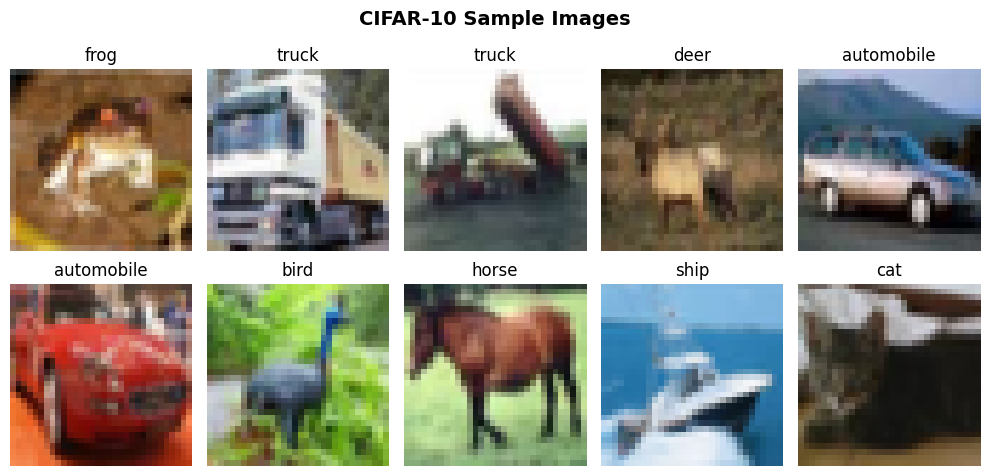

Training samples: 50000, Test samples: 10000
Image shape: (32, 32, 3)


In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

### Activity 2: Normalize the Data

In [9]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0
print("Pixel values normalized to [0, 1] ✅")
print(f"Min: {x_train.min():.2f}, Max: {x_train.max():.2f}")

Pixel values normalized to [0, 1] ✅
Min: 0.00, Max: 1.00


### Activity 3: Build a Simple CNN Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### Activity 4: Compile the Model

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Model compiled with Adam optimizer ✅")

Model compiled with Adam optimizer ✅


### Activity 5: Train the Model

In [12]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.3682 - loss: 1.7157 - val_accuracy: 0.4707 - val_loss: 1.4479
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4827 - loss: 1.4227 - val_accuracy: 0.5856 - val_loss: 1.1780
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5316 - loss: 1.3059 - val_accuracy: 0.6130 - val_loss: 1.1145
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5662 - loss: 1.2122 - val_accuracy: 0.6401 - val_loss: 1.0444
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5904 - loss: 1.1505 - val_accuracy: 0.6518 - val_loss: 1.0049
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6073 - loss: 1.1078 - val_accuracy: 0.6574 - val_loss: 0.9895
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6235 - loss: 1.0622 - val_accuracy: 0.6724 - val_loss: 0.9378
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6358 - loss: 1.0283 -

### Activity 6: Evaluate the Model

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6895 - loss: 0.9051
Test Loss:     0.9051
Test Accuracy: 0.6895


### Activity 7: Plot Accuracy and Loss Curves

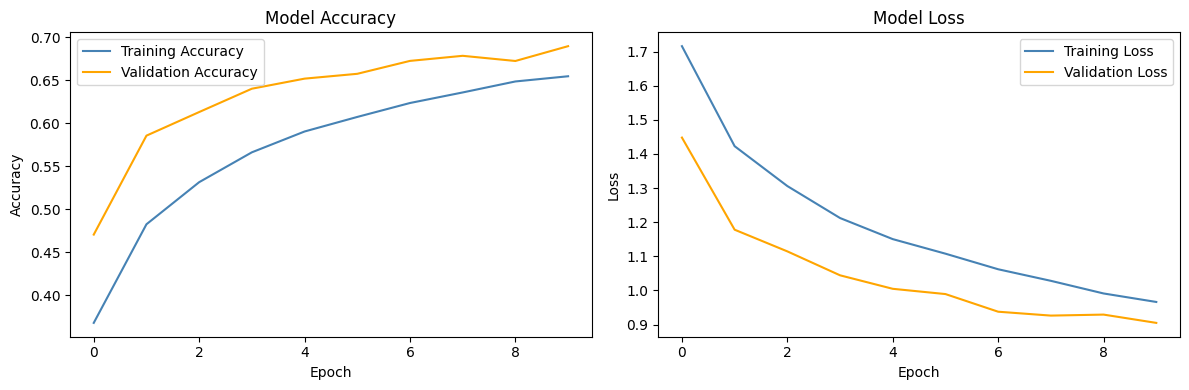

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Training Loss',   color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Activity 8: Data Augmentation

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(x_train)
print("ImageDataGenerator fitted on training data ✅")

ImageDataGenerator fitted on training data ✅


### Activity 9: Retrain Model with Augmented Data

In [16]:
history_aug = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                        epochs=10,
                        validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4831 - loss: 1.4588 - val_accuracy: 0.6041 - val_loss: 1.1319
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.4980 - loss: 1.4043 - val_accuracy: 0.6169 - val_loss: 1.0862
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.5059 - loss: 1.3810 - val_accuracy: 0.6204 - val_loss: 1.0708
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5181 - loss: 1.3566 - val_accuracy: 0.6286 - val_loss: 1.0592
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.5245 - loss: 1.3413 - val_accuracy: 0.6541 - val_loss: 0.9814
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5275 - loss: 1.3284 - val_accuracy: 0.6455 - val_loss: 1.0080
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5340 - loss: 1.3139 - val_accuracy: 0.6621 - val_loss: 0.9685
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5386 -

### Activity 10: Predict on New Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step


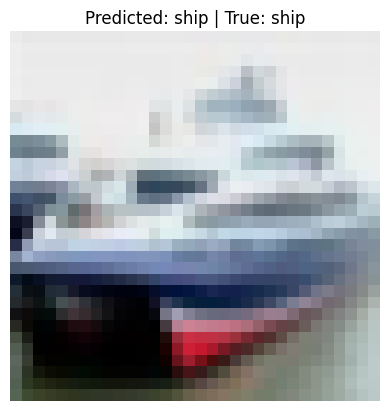

Predicted class: ship


In [17]:
import numpy as np
sample = np.expand_dims(x_test[1], axis=0)
prediction = model.predict(sample)
predicted_label = class_names[np.argmax(prediction)]
true_label      = class_names[y_test[1][0]]

plt.imshow(x_test[1])
plt.title(f"Predicted: {predicted_label} | True: {true_label}")
plt.axis('off')
plt.show()
print(f"Predicted class: {predicted_label}")

---
# 🎯 Graded Tasks

## Task 1 — MNIST CNN (>98% Accuracy)
**Scenario:** A company wants to classify handwritten digits. Load the MNIST dataset and train a CNN to achieve over 98% accuracy.

In [18]:
# ─── Load MNIST ───────────────────────────────────────────────
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_mnist_train, y_mnist_train), (x_mnist_test, y_mnist_test) = mnist.load_data()

# Reshape → (N, 28, 28, 1) and normalize
x_mnist_train = x_mnist_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_mnist_test  = x_mnist_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

print(f"Train shape: {x_mnist_train.shape} | Test shape: {x_mnist_test.shape}")

Train shape: (60000, 28, 28, 1) | Test shape: (10000, 28, 28, 1)


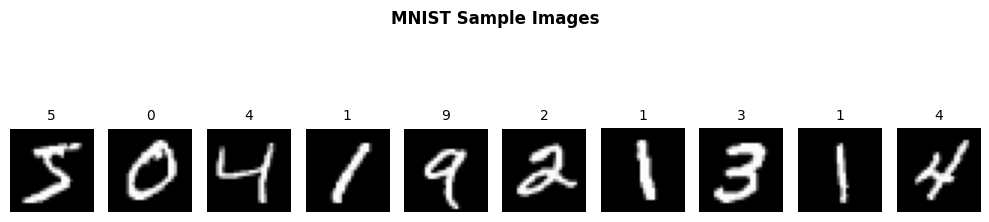

In [19]:
# ─── Visualize a few samples ───────────────────────────────────
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_mnist_train[i].squeeze(), cmap='gray')
    plt.title(str(y_mnist_train[i]), fontsize=10)
    plt.axis('off')
plt.suptitle('MNIST Sample Images', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ─── Build CNN for MNIST ───────────────────────────────────────
mnist_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

mnist_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
mnist_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [21]:
# ─── Train ─────────────────────────────────────────────────────
early_stop_mnist = EarlyStopping(monitor='val_accuracy', patience=3,
                                 restore_best_weights=True, verbose=1)

history_mnist = mnist_model.fit(
    x_mnist_train, y_mnist_train,
    epochs=15, batch_size=64,
    validation_data=(x_mnist_test, y_mnist_test),
    callbacks=[early_stop_mnist]
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9490 - loss: 0.1634 - val_accuracy: 0.9852 - val_loss: 0.0451
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9802 - loss: 0.0648 - val_accuracy: 0.9899 - val_loss: 0.0296
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9840 - loss: 0.0503 - val_accuracy: 0.9927 - val_loss: 0.0226
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9914 - val_loss: 0.0240
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9876 - loss: 0.0402 - val_accuracy: 0.9901 - val_loss: 0.0282
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9893 - loss: 0.0348 - val_accuracy: 0.9927 - val_loss: 0.0236
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [22]:
# ─── Evaluate ─────────────────────────────────────────────────
loss_m, acc_m = mnist_model.evaluate(x_mnist_test, y_mnist_test, verbose=0)
print(f"✅ MNIST Test Accuracy : {acc_m*100:.2f}%")
print(f"   MNIST Test Loss     : {loss_m:.4f}")

if acc_m >= 0.98:
    print("🎉 Target of 98% accuracy achieved!")
else:
    print("⚠️  Accuracy below 98% — try training for more epochs.")

✅ MNIST Test Accuracy : 99.27%
   MNIST Test Loss     : 0.0226
🎉 Target of 98% accuracy achieved!


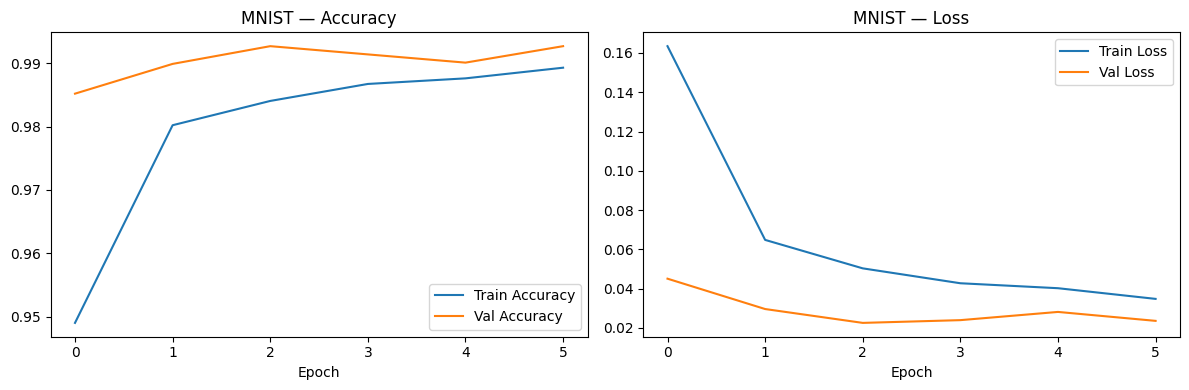

In [23]:
# ─── Plot training curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_mnist.history[metric],        label=f'Train {metric.capitalize()}')
    ax.plot(history_mnist.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
    ax.set_title(f'MNIST — {metric.capitalize()}')
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

---
## Task 2 — Wildlife Animal Classification (5 Classes from CIFAR-10)
**Scenario:** A wildlife organization has images of 5 animal classes. Simulate using CIFAR-10 animal classes (bird, cat, deer, dog, horse). Train and evaluate performance.

In [24]:
# ─── Load CIFAR-10 fresh and filter 5 animal classes ──────────
(xc, yc), (xc_test, yc_test) = cifar10.load_data()
xc = xc / 255.0;  xc_test = xc_test / 255.0

# CIFAR-10 labels: 2=bird, 3=cat, 4=deer, 5=dog, 7=horse
animal_classes   = [2, 3, 4, 5, 7]
animal_names_map = {2:'bird', 3:'cat', 4:'deer', 5:'dog', 7:'horse'}

def filter_classes(X, Y, class_list):
    """Keep only rows whose label is in class_list; remap labels 0..N-1."""
    label_map  = {old: new for new, old in enumerate(sorted(class_list))}
    mask       = np.isin(Y.flatten(), class_list)
    X_filtered = X[mask]
    Y_filtered = np.array([label_map[y] for y in Y.flatten()[mask]])
    return X_filtered, Y_filtered

x_animal_train, y_animal_train = filter_classes(xc,      yc,      animal_classes)
x_animal_test,  y_animal_test  = filter_classes(xc_test, yc_test, animal_classes)
animal_names = ['bird', 'cat', 'deer', 'dog', 'horse']  # 0-indexed

print(f"Animal Train: {x_animal_train.shape} | Animal Test: {x_animal_test.shape}")

Animal Train: (25000, 32, 32, 3) | Animal Test: (5000, 32, 32, 3)


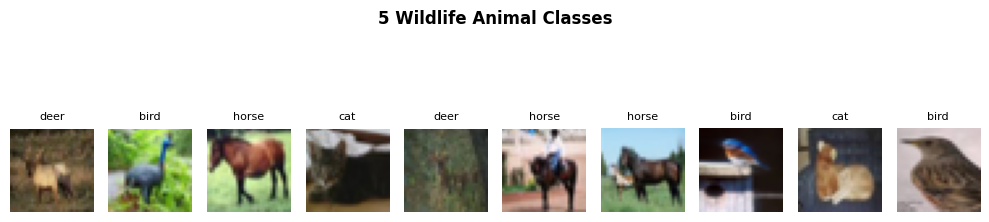

In [25]:
# ─── Visualize samples ────────────────────────────────────────
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_animal_train[i])
    plt.title(animal_names[y_animal_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('5 Wildlife Animal Classes', fontweight='bold')
plt.tight_layout(); plt.show()

In [26]:
# ─── Build & Train CNN ────────────────────────────────────────
wildlife_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 animal classes
])

wildlife_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_wildlife = wildlife_model.fit(
    x_animal_train, y_animal_train,
    epochs=20, batch_size=64,
    validation_data=(x_animal_test, y_animal_test),
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=4,
                             restore_best_weights=True, verbose=1)]
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3615 - loss: 1.5083 - val_accuracy: 0.2398 - val_loss: 4.1139
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4449 - loss: 1.3200 - val_accuracy: 0.4912 - val_loss: 1.2215
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5005 - loss: 1.2138 - val_accuracy: 0.5268 - val_loss: 1.2154
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5406 - loss: 1.1409 - val_accuracy: 0.5820 - val_loss: 1.0633
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5643 - loss: 1.0877 - val_accuracy: 0.5852 - val_loss: 1.0293
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5968 - loss: 1.0260 - val_accuracy: 0.6298 - val_loss: 0.9514
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6136 - loss: 0.9855 - val_accuracy: 0.6316 - val_loss: 0.9457
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6367 - loss: 0.9389 - val_accuracy: 

In [27]:
# ─── Evaluate & Report ────────────────────────────────────────
loss_w, acc_w = wildlife_model.evaluate(x_animal_test, y_animal_test, verbose=0)
print(f"Wildlife Model Test Accuracy: {acc_w*100:.2f}%")

y_pred_w = np.argmax(wildlife_model.predict(x_animal_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_animal_test, y_pred_w, target_names=animal_names))

Wildlife Model Test Accuracy: 73.36%
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report:
              precision    recall  f1-score   support

        bird       0.69      0.79      0.74      1000
         cat       0.72      0.57      0.64      1000
        deer       0.75      0.79      0.77      1000
         dog       0.66      0.73      0.69      1000
       horse       0.87      0.79      0.83      1000

    accuracy                           0.73      5000
   macro avg       0.74      0.73      0.73      5000
weighted avg       0.74      0.73      0.73      5000



---
## Task 3 — Lightweight CNN for Mobile (Fewer Parameters)
**Scenario:** Your team is working on real-time object classification on mobile. Build a smaller CNN architecture with fewer parameters.

In [28]:
# ─── MobileNet-inspired lightweight CNN ───────────────────────
# Uses Depthwise Separable Convolutions via SeparableConv2D
from tensorflow.keras.layers import SeparableConv2D, GlobalAveragePooling2D

(x_c10, y_c10), (x_c10t, y_c10t) = cifar10.load_data()
x_c10  = x_c10  / 255.0
x_c10t = x_c10t / 255.0

def build_lightweight_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        # Standard conv for first layer (cheaper since input channels=3)
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D((2,2)),

        # Depthwise Separable Convolutions — drastically fewer parameters
        SeparableConv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        SeparableConv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        # Global Average Pooling replaces Flatten + Dense (saves parameters)
        GlobalAveragePooling2D(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

# ─── Compare parameter counts ────────────────────────────────
standard_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(), Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(), Flatten(),
    Dense(64, activation='relu'), Dense(10, activation='softmax')
])

light_cnn = build_lightweight_cnn()

std_params   = standard_cnn.count_params()
light_params = light_cnn.count_params()

print(f"Standard CNN Parameters  : {std_params:,}")
print(f"Lightweight CNN Parameters: {light_params:,}")
print(f"Parameter Reduction      : {(1 - light_params/std_params)*100:.1f}%")
light_cnn.summary()

Standard CNN Parameters  : 167,562
Lightweight CNN Parameters: 8,346
Parameter Reduction      : 95.0%


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 16, 16, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 8, 8, 64)       │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,346 (32.60 KB)

 Trainable params: 8,346 (32.60 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ─── Train Lightweight CNN ────────────────────────────────────
light_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_light = light_cnn.fit(
    x_c10, y_c10,
    epochs=15, batch_size=64,
    validation_data=(x_c10t, y_c10t),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=1)]
)

_, acc_light = light_cnn.evaluate(x_c10t, y_c10t, verbose=0)
print(f"\n✅ Lightweight CNN Test Accuracy: {acc_light*100:.2f}%")
print(f"   Model size suitable for mobile deployment!")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2049 - loss: 2.0599 - val_accuracy: 0.2422 - val_loss: 2.0085
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2900 - loss: 1.8379 - val_accuracy: 0.3485 - val_loss: 1.7265
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3348 - loss: 1.7458 - val_accuracy: 0.3836 - val_loss: 1.6518
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3627 - loss: 1.6933 - val_accuracy: 0.3991 - val_loss: 1.6120
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3840 - loss: 1.6491 - val_accuracy: 0.4198 - val_loss: 1.5529
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3963 - loss: 1.6209 - val_accuracy: 0.4350 - val_loss: 1.5135
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4107 - loss: 1.5871 - val_accuracy: 0.4409 - val_loss: 1.5131
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4232 - loss: 1.5563 - val_accuracy: 

---
## Task 4 — Dropout & Data Augmentation: Before vs After Comparison
**Scenario:** Add dropout and data augmentation to prevent overfitting in your CIFAR-10 model. Show before and after accuracy comparisons.

In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

# ─── Load & prepare data ──────────────────────────────────────────────────────
(x_t4_np, y_t4_np), (x_t4v_np, y_t4v_np) = cifar10.load_data()

# Explicitly convert to TensorFlow tensors with correct dtypes, then process
x_t4  = tf.convert_to_tensor(x_t4_np, dtype=tf.float32) / 255.0
x_t4v = tf.convert_to_tensor(x_t4v_np, dtype=tf.float32) / 255.0
y_t4  = tf.convert_to_tensor(y_t4_np, dtype=tf.int32)
y_t4v = tf.convert_to_tensor(y_t4v_np, dtype=tf.int32)

# Squeeze y_t4 and y_t4v after conversion to tensor if they are still (N, 1)
if len(y_t4.shape) == 2 and y_t4.shape[1] == 1:
    y_t4 = tf.squeeze(y_t4)
if len(y_t4v.shape) == 2 and y_t4v.shape[1] == 1:
    y_t4v = tf.squeeze(y_t4v)


# ─── Augmentation fn: input is a BATCH [batch,32,32,3] ───────────────────────
def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    # ✅ FIX: 4 padding pairs for rank-4 tensor [batch, H, W, C]
    x = tf.pad(x, [[0,0], [4,4], [4,4], [0,0]])
    x = tf.image.random_crop(x, [tf.shape(x)[0], 32, 32, 3])
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

BATCH  = 64
EPOCHS = 15

# Create tf.data.Dataset for both baseline and regularized models
base_train_ds = (tf.data.Dataset.from_tensor_slices((x_t4, y_t4))
                 .shuffle(50000)
                 .batch(BATCH)
                 .prefetch(tf.data.AUTOTUNE))

base_val_ds = (tf.data.Dataset.from_tensor_slices((x_t4v, y_t4v))
               .batch(BATCH)
               .prefetch(tf.data.AUTOTUNE))

train_ds = (tf.data.Dataset.from_tensor_slices((x_t4, y_t4))
            .shuffle(50000)
            .batch(BATCH)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((x_t4v, y_t4v))
          .batch(BATCH)
          .prefetch(tf.data.AUTOTUNE))

# ─── Models ───────────────────────────────────────────────────────────────────
def build_base_model():
    m = Sequential([
        Input(shape=(32,32,3)), # Explicitly define input layer
        Conv2D(32,(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Conv2D(64,(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
    return m

def build_regularized_model():
    m = Sequential([
        Input(shape=(32,32,3)), # Explicitly define input layer
        Conv2D(32,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Conv2D(64,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10,  activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
    return m

# ─── Train ────────────────────────────────────────────────────────────────────
print("Training baseline model (no regularization)...")
base_model = build_base_model()
hist_base  = base_model.fit(base_train_ds,
                             epochs=EPOCHS,
                             validation_data=base_val_ds, verbose=1)

print("\nTraining regularized model (Dropout + BatchNorm + Augmentation)...")
reg_model = build_regularized_model()
hist_reg  = reg_model.fit(train_ds,
                           epochs=EPOCHS,
                           validation_data=val_ds, verbose=1)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
_, acc_base = base_model.evaluate(base_val_ds, verbose=0)
_, acc_reg  = reg_model.evaluate(val_ds,         verbose=0)

print(f"\n📊 Results:")
print(f"   Baseline    Test Accuracy : {acc_base*100:.2f}%")
print(f"   Regularized Test Accuracy : {acc_reg*100:.2f}%")
print(f"   Improvement               : +{(acc_reg - acc_base)*100:.2f}%")

Training baseline model (no regularization)...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4476 - loss: 1.5380 - val_accuracy: 0.5525 - val_loss: 1.2547
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5932 - loss: 1.1577 - val_accuracy: 0.6178 - val_loss: 1.0891
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6478 - loss: 1.0104 - val_accuracy: 0.6534 - val_loss: 0.9983
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6774 - loss: 0.9221 - val_accuracy: 0.6707 - val_loss: 0.9531
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7034 - loss: 0.8614 - val_accuracy: 0.6637 - val_loss: 0.9616
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7188 - loss: 0.8108 - val_accuracy: 0.6795 - val_loss: 0.9402
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7344 - loss: 0.7678 - val_accuracy: 0.6979 - val_loss: 0.8922
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - a

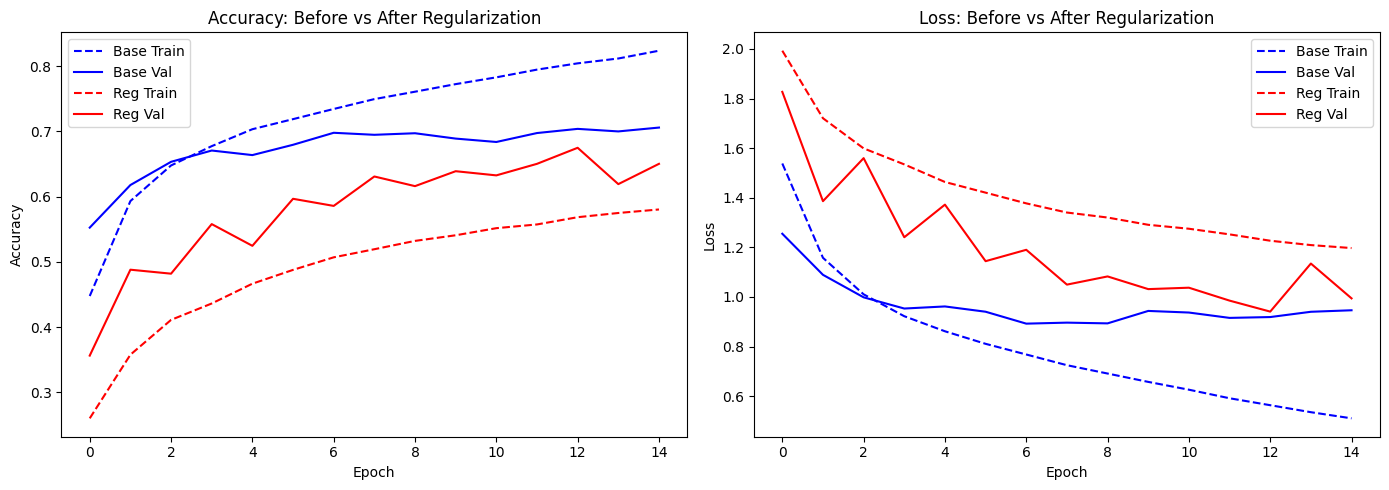

🔍 Observation: The gap between train/val curves shrinks with regularization — less overfitting!


In [30]:
import matplotlib.pyplot as plt

# ─── Visualize Overfitting: Before vs After ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(hist_base.history['accuracy'],     'b--', label='Base Train')
axes[0].plot(hist_base.history['val_accuracy'], 'b-',  label='Base Val')
axes[0].plot(hist_reg.history['accuracy'],      'r--', label='Reg Train')
axes[0].plot(hist_reg.history['val_accuracy'],  'r-',  label='Reg Val')
axes[0].set_title('Accuracy: Before vs After Regularization')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(hist_base.history['loss'],     'b--', label='Base Train')
axes[1].plot(hist_base.history['val_loss'], 'b-',  label='Base Val')
axes[1].plot(hist_reg.history['loss'],      'r--', label='Reg Train')
axes[1].plot(hist_reg.history['val_loss'],  'r-',  label='Reg Val')
axes[1].set_title('Loss: Before vs After Regularization')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout(); plt.show()
print("🔍 Observation: The gap between train/val curves shrinks with regularization — less overfitting!")

---
## Task 5 — Visualize Feature Maps After First Conv Layer
**Scenario:** Visualize the feature maps after the first convolution layer using any sample image.

In [19]:
# ─── Build a fresh CNN just for visualization ─────────────────
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input # Added Input
import tensorflow as tf # Import tensorflow for explicit tensor conversion

(x_t5_np, y_t5_np), (x_t5v_np, y_t5v_np) = cifar10.load_data()

# Explicitly convert to TensorFlow tensors with correct dtypes, then process
x_t5  = tf.convert_to_tensor(x_t5_np, dtype=tf.float32) / 255.0
x_t5v = tf.convert_to_tensor(x_t5v_np, dtype=tf.float32) / 255.0
y_t5  = tf.convert_to_tensor(y_t5_np, dtype=tf.int64) # Changed to int64
y_t5v = tf.convert_to_tensor(y_t5v_np, dtype=tf.int64) # Changed to int64

# Squeeze y_t5 and y_t5v after conversion to tensor if they are still (N, 1)
if len(y_t5.shape) == 2 and y_t5.shape[1] == 1:
    y_t5 = tf.squeeze(y_t5)
if len(y_t5v.shape) == 2 and y_t5v.shape[1] == 1:
    y_t5v = tf.squeeze(y_t5v)


vis_model = Sequential([
    Input(shape=(32,32,3)), # Explicitly define input layer
    Conv2D(32, (3,3), activation='relu', padding='same', name='conv1'), # Removed input_shape from Conv2D
    MaxPooling2D((2,2), name='pool1'),
    Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
    MaxPooling2D((2,2), name='pool2'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
vis_model.compile('adam', 'sparse_categorical_crossentropy', ['accuracy'])
vis_model.fit(x_t5, y_t5, epochs=5, batch_size=64,
              validation_data=(x_t5v, y_t5v), verbose=1)

print("Model trained. Now extracting feature maps...")

Epoch 1/5


ValueError: dtype='string' is not a valid dtype for Keras type promotion.

In [8]:
# ─── Create Feature Map Extractor ────────────────────────────
from tensorflow.keras.models import Model
import numpy as np # Ensure numpy is imported for np.expand_dims
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'] # Added definition of class_names

# Extract output of first conv layer
feature_map_model = Model(
    inputs  = vis_model.input,
    outputs = vis_model.get_layer('conv1').output
)

# Pick a sample image
sample_idx   = 5
sample_img   = x_t5v[sample_idx]
sample_input = np.expand_dims(sample_img, axis=0)

# Get feature maps
feature_maps = feature_map_model.predict(sample_input)  # shape: (1, 32, 32, 32)

# ─── Visualize original image ────────────────────────────────
plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(f"Input Image: {class_names[y_t5v[sample_idx]]}") # y_t5v is now squeezed, no need for [0]
plt.axis('off')
plt.show()

# ─── Visualize first 16 feature maps ─────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Feature Maps from Conv Layer 1 (32 filters)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature map shape:", feature_maps.shape)
print("Each feature map highlights different spatial patterns (edges, textures, etc.)")

AttributeError: The layer sequential_3 has never been called and thus has no defined input.

---
## Task 6 — Save & Load Model for Inference
**Scenario:** Save your trained model and load it again for inference on unseen data.

In [20]:
# ─── Save the model ──────────────────────────────────────────
MODEL_PATH = 'cifar10_cnn_model.h5'
vis_model.save(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")
print(f"   File size: {__import__('os').path.getsize(MODEL_PATH) / 1024:.1f} KB")

✅ Model saved to: cifar10_cnn_model.h5
   File size: 1135.4 KB


In [21]:
# ─── Load the model back ──────────────────────────────────────
from tensorflow.keras.models import load_model

loaded_model = load_model(MODEL_PATH)
print("✅ Model loaded successfully!")
loaded_model.summary()

✅ Model loaded successfully!


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,252 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} Attempting to slice scalar input. [Op:StridedSlice] name: strided_slice/

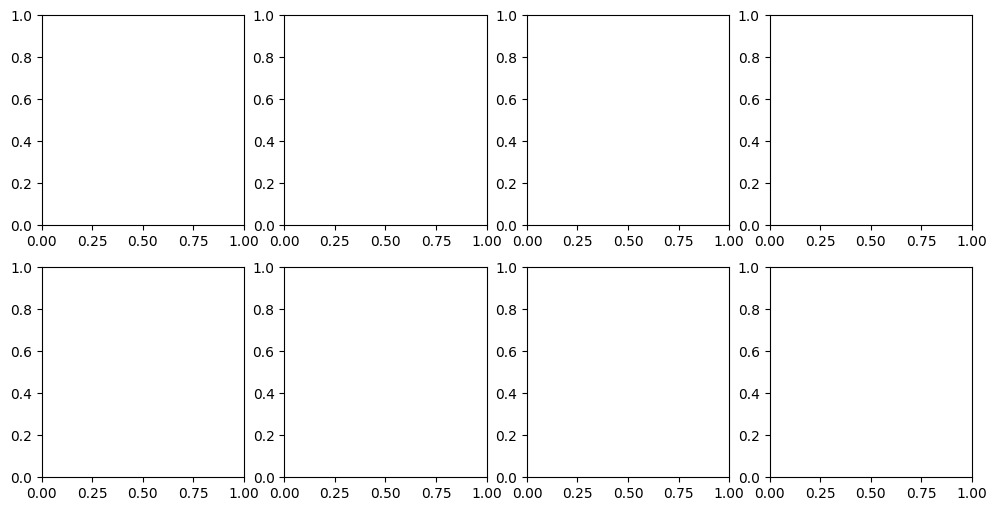

In [11]:
# ─── Inference on unseen test images ─────────────────────────
n_samples = 8
indices   = np.random.choice(len(x_t5v), n_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flat, indices):
    img  = x_t5v[idx]
    pred = loaded_model.predict(np.expand_dims(img, 0), verbose=0)
    pred_class = class_names[np.argmax(pred)]
    true_class = class_names[y_t5v[idx][0]]
    confidence = np.max(pred) * 100

    ax.imshow(img)
    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}\n{confidence:.1f}%",
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Inference on Unseen Data (Green=Correct, Red=Wrong)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()
print("Model saved and reloaded successfully for inference ✅")

---
## Task 7 — Grayscale vs RGB CIFAR-10 Comparison
**Scenario:** Train the CNN on grayscale versions of CIFAR-10. Compare results with RGB input.

In [ ]:
# ─── Load and prepare data ────────────────────────────────────
(x_rgb, y_rgb), (x_rgb_test, y_rgb_test) = cifar10.load_data()
x_rgb      = x_rgb      / 255.0
x_rgb_test = x_rgb_test / 255.0

# Convert to grayscale: luminance formula
x_gray      = np.dot(x_rgb,      [0.2989, 0.5870, 0.1140])[..., np.newaxis]
x_gray_test = np.dot(x_rgb_test, [0.2989, 0.5870, 0.1140])[..., np.newaxis]

print(f"RGB   shape: {x_rgb.shape}")
print(f"Gray  shape: {x_gray.shape}")

# Visualize side-by-side
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0][i].imshow(x_rgb[i]);                      axes[0][i].set_title(class_names[y_rgb[i][0]]); axes[0][i].axis('off')
    axes[1][i].imshow(x_gray[i].squeeze(), cmap='gray'); axes[1][i].axis('off')
axes[0][0].set_ylabel('RGB',  rotation=0, labelpad=30, fontsize=12)
axes[1][0].set_ylabel('Gray', rotation=0, labelpad=30, fontsize=12)
plt.suptitle('RGB vs Grayscale CIFAR-10', fontweight='bold'); plt.tight_layout(); plt.show()

In [12]:
# ─── Build same architecture for both ────────────────────────
def build_cnn_for_channels(channels):
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(32, 32, channels)),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    m.compile('adam', 'sparse_categorical_crossentropy', ['accuracy'])
    return m

EPOCHS_T7 = 10

print("Training RGB model...")
rgb_model  = build_cnn_for_channels(3)
hist_rgb   = rgb_model.fit(x_rgb, y_rgb, epochs=EPOCHS_T7, batch_size=64,
                            validation_data=(x_rgb_test, y_rgb_test), verbose=0)

print("Training Grayscale model...")
gray_model = build_cnn_for_channels(1)
hist_gray  = gray_model.fit(x_gray, y_rgb, epochs=EPOCHS_T7, batch_size=64,
                             validation_data=(x_gray_test, y_rgb_test), verbose=0)

_, acc_rgb  = rgb_model.evaluate(x_rgb_test,  y_rgb_test, verbose=0)
_, acc_gray = gray_model.evaluate(x_gray_test, y_rgb_test, verbose=0)

print(f"\n📊 Comparison:")
print(f"   RGB   Test Accuracy: {acc_rgb  * 100:.2f}%")
print(f"   Gray  Test Accuracy: {acc_gray * 100:.2f}%")
print(f"   Difference (RGB - Gray): {(acc_rgb - acc_gray)*100:.2f}%")
print("\n💡 RGB outperforms grayscale because color is a crucial feature for object recognition.")

Training RGB model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'Dropout' is not defined

In [13]:
# ─── Plot comparison curves ───────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(hist_rgb.history['val_accuracy'],  'b-o', label='RGB Validation')
plt.plot(hist_gray.history['val_accuracy'], 'r-s', label='Grayscale Validation')
plt.title('RGB vs Grayscale — Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

NameError: name 'hist_rgb' is not defined

<Figure size 1000x400 with 0 Axes>

---
## Task 8 — Compare Optimizers: Adam vs SGD vs RMSprop
**Scenario:** Use different optimizers (SGD, RMSprop) and compare model performance.

In [14]:
# ─── Load Data ───────────────────────────────────────────────
(x_t8, y_t8), (x_t8v, y_t8v) = cifar10.load_data()
x_t8  = x_t8  / 255.0
x_t8v = x_t8v / 255.0

def build_opt_model():
    """Same architecture — only optimizer changes."""
    return Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10, activation='softmax')
    ])

optimizers = {
    'Adam'    : tf.keras.optimizers.Adam(learning_rate=0.001),
    'SGD'     : tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop' : tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

histories_opt = {}
results_opt   = {}
EPOCHS_T8 = 10

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name}...")
    m = build_opt_model()
    m.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(x_t8, y_t8, epochs=EPOCHS_T8, batch_size=64,
              validation_data=(x_t8v, y_t8v), verbose=0)
    _, acc = m.evaluate(x_t8v, y_t8v, verbose=0)
    histories_opt[opt_name] = h
    results_opt[opt_name]   = acc
    print(f"  → Test Accuracy: {acc*100:.2f}%")

print("\n📊 Optimizer Comparison Summary:")
for opt_name, acc in results_opt.items():
    bar = '█' * int(acc * 50)
    print(f"  {opt_name:<10}: {acc*100:.2f}% {bar}")

Training with Adam...


NameError: name 'Dropout' is not defined

In [ ]:
# ─── Plot Optimizer Comparison ────────────────────────────────
colors = {'Adam': 'steelblue', 'SGD': 'tomato', 'RMSprop': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name, h in histories_opt.items():
    axes[0].plot(h.history['val_accuracy'],  label=opt_name, color=colors[opt_name])
    axes[1].plot(h.history['val_loss'],      label=opt_name, color=colors[opt_name])

axes[0].set_title('Validation Accuracy by Optimizer'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Validation Loss by Optimizer');     axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss');     axes[1].legend()
plt.tight_layout(); plt.show()

print("💡 Adam typically converges fastest; SGD with momentum can generalize well with enough epochs.")

---
## Task 9 — Early Stopping
**Scenario:** Implement early stopping during training and explain its benefit.

In [ ]:
# ─── Data ────────────────────────────────────────────────────
(x_t9, y_t9), (x_t9v, y_t9v) = cifar10.load_data()
x_t9  = x_t9  / 255.0
x_t9v = x_t9v / 255.0

def build_model_t9():
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    m.compile('adam', 'sparse_categorical_crossentropy', ['accuracy'])
    return m

MAX_EPOCHS = 50  # Deliberately high — early stopping will stop before this

# Define early stopping callback with detailed settings
early_stop = EarlyStopping(
    monitor           = 'val_loss',     # Metric to watch
    patience          = 5,              # Stop after 5 epochs of no improvement
    restore_best_weights = True,        # Revert to best weights, not last
    min_delta         = 0.001,          # Minimum change to qualify as improvement
    verbose           = 1
)

print(f"Training with max {MAX_EPOCHS} epochs — EarlyStopping will halt training automatically...")
es_model  = build_model_t9()
hist_es   = es_model.fit(x_t9, y_t9, epochs=MAX_EPOCHS, batch_size=64,
                          validation_data=(x_t9v, y_t9v),
                          callbacks=[early_stop])

actual_epochs = len(hist_es.history['loss'])
_, acc_es = es_model.evaluate(x_t9v, y_t9v, verbose=0)

print(f"\n✅ Early Stopping triggered at epoch {actual_epochs}/{MAX_EPOCHS}")
print(f"   Saved {MAX_EPOCHS - actual_epochs} unnecessary epochs of training!")
print(f"   Final Test Accuracy: {acc_es*100:.2f}%")

In [ ]:
# ─── Plot with Early Stop annotation ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(hist_es.history[metric],         label=f'Train {metric.capitalize()}')
    ax.plot(hist_es.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
    ax.axvline(x=actual_epochs - early_stop.patience - 1,
               color='red', linestyle='--', label='Best Epoch')
    ax.axvline(x=actual_epochs - 1,
               color='orange', linestyle=':', label='Stopped At')
    ax.set_title(f'{metric.capitalize()} with Early Stopping')
    ax.set_xlabel('Epoch'); ax.legend()

plt.tight_layout(); plt.show()

print("""
📚 Early Stopping Benefits:
  1. Prevents overfitting by stopping before the model memorizes training data
  2. Saves computation time — no wasted training epochs
  3. restore_best_weights=True ensures best model is returned, not last
  4. Acts as implicit regularization without changing architecture
""")

---
## Task 10 — Evaluation Metrics: Confusion Matrix, Precision, Recall
**Scenario:** Using model evaluation metrics (Confusion Matrix, Precision, Recall), assess your trained model on CIFAR-10.

In [22]:
# ─── Use the model from Task 9 (or retrain if needed) ────────
from tensorflow.keras.layers import BatchNormalization, Dropout # Added these imports
from tensorflow.keras.callbacks import EarlyStopping # Added EarlyStopping import

(x_t10, y_t10), (x_t10v, y_t10v) = cifar10.load_data()
x_t10  = x_t10  / 255.0
x_t10v = x_t10v / 255.0

# Build and train a clean model for fair evaluation
eval_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(), MaxPooling2D(), Dropout(0.25),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(), Dropout(0.25),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(), Dropout(0.3),
    Flatten(),
    Dense(256, activation='relu'), Dropout(0.5),
    Dense(10, activation='softmax')
])
eval_model.compile('adam', 'sparse_categorical_crossentropy', ['accuracy'])

eval_model.fit(x_t10, y_t10, epochs=15, batch_size=64,
               validation_data=(x_t10v, y_t10v),
               callbacks=[EarlyStopping(patience=4, restore_best_weights=True, verbose=0)],
               verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'EarlyStopping' is not defined

In [ ]:
# ─── Predictions ─────────────────────────────────────────────
y_pred_probs = eval_model.predict(x_t10v)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_t10v.flatten()

# ─── Overall accuracy ────────────────────────────────────────
_, test_acc_final = eval_model.evaluate(x_t10v, y_t10v, verbose=0)
print(f"Overall Test Accuracy: {test_acc_final*100:.2f}%")

In [17]:
# ─── Confusion Matrix ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='grey')
plt.title('Confusion Matrix — CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'y_true' is not defined

In [18]:
# ─── Classification Report (Precision, Recall, F1) ───────────
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print("=" * 60)
print(report)

NameError: name 'y_true' is not defined

In [ ]:
# ─── Per-class Precision & Recall Bar Chart ───────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall    = recall_score(y_true, y_pred, average=None)
f1        = f1_score(y_true, y_pred, average=None)

x_pos = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x_pos - width,      precision, width, label='Precision', color='steelblue')
ax.bar(x_pos,              recall,    width, label='Recall',    color='tomato')
ax.bar(x_pos + width,      f1,        width, label='F1-Score',  color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1-Score', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=0.7, color='grey', linestyle='--', alpha=0.5, label='0.7 threshold')

# Annotate bars
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=7)

plt.tight_layout(); plt.show()

print(f"\n📊 Macro Averages:")
print(f"   Precision : {precision.mean():.4f}")
print(f"   Recall    : {recall.mean():.4f}")
print(f"   F1-Score  : {f1.mean():.4f}")
print("\n💡 Observation: 'cat' and 'dog' are often confused since they share visual features.")

---
## ✅ Lab Summary

| Task | Description | Key Technique |
|------|------------|---------------|
| 1 | MNIST CNN → 98% accuracy | BatchNorm + Dropout |
| 2 | Wildlife 5-class classification | Filtered CIFAR-10 |
| 3 | Lightweight mobile CNN | SeparableConv2D + GAP |
| 4 | Overfitting prevention | Dropout + Augmentation |
| 5 | Feature map visualization | Intermediate Model output |
| 6 | Save & Load model | model.save() / load_model() |
| 7 | RGB vs Grayscale | Luminance conversion |
| 8 | Optimizer comparison | Adam vs SGD vs RMSprop |
| 9 | Early Stopping | EarlyStopping callback |
| 10 | Evaluation metrics | Confusion Matrix, Precision, Recall, F1 |
